# Offline Reinforcement Learning — Distribution Shift, CQL and IQL

On **CartPole-v1**, validates the core problem of offline RL and its two solutions:

1. **Extrapolation error**: naive offline DQN's Q estimates decouple from true returns, ending below the behavior-cloning (BC) pass line;
2. **CQL**: the conservative penalty anchors Q on the data, restoring returns to the BC level;
3. **IQL**: in-sample learning (expectile regression + max-free targets), likewise restoring returns to BC.

The dataset (`offline_rl_medium.npz`, 30k transitions) was collected by a "medium checkpoint" behavior policy with ε=0.3 randomness and cached as the single source of truth; naive / CQL / IQL all train offline on this fixed dataset (3 seeds, 42/43/44).

Output figures:
- `fig1_ood_overestimation.pdf`
- `fig2_cql_conservatism.pdf`
- `fig3_iql_insample.pdf`

Estimated runtime: about 5–8 minutes (CPU or GPU).

In [1]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import gymnasium as gym
import matplotlib
import matplotlib.pyplot as plt
torch.set_num_threads(4)

matplotlib.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
})

# ---------------- config ----------------
DATA_DIR = '.'                 # notebook 所在目录（Jupyter 默认 cwd）
NPZ = os.path.join(DATA_DIR, 'offline_rl_medium.npz')
GAMMA = 0.99
LR = 3e-4
HIDDEN = 64
UPD = 5000                     # 离线训练步数
EVAL_EVERY = 500               # 每多少步评估一次
EVAL_EPS = 10                  # 每次评估的回合数
BATCH = 128
SEEDS = [42, 43, 44]
BC_SEEDS = [1, 2, 3, 4, 5]     # BC 训练种子（画区间带）
BC_UPD = 4000
TAU = 0.7                      # IQL expectile
LAM = 3.0                      # IQL AWR 温度
CQL_ALPHA = 1.0                # CQL 保守强度

BLUE = '#2166AC'
RED = '#D6604D'
GRAY = '#808080'
GREEN = '#1B7837'

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


In [2]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


def style_axes(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)


class QNet(nn.Module):
    """Q 网络：输入状态，输出每个离散动作的 Q 值。"""
    def __init__(self, sd, na):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(sd, HIDDEN), nn.ReLU(),
            nn.Linear(HIDDEN, HIDDEN), nn.ReLU(),
            nn.Linear(HIDDEN, na))

    def forward(self, s):
        return self.net(s)


class Actor(nn.Module):
    """离散策略网络（BC / IQL 的 actor）：输入状态，输出 logits。"""
    def __init__(self, sd, na):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(sd, HIDDEN), nn.ReLU(),
            nn.Linear(HIDDEN, HIDDEN), nn.ReLU(),
            nn.Linear(HIDDEN, na))

    def forward(self, s):
        return self.net(s)


class VNet(nn.Module):
    """IQL 的状态价值网络。"""
    def __init__(self, sd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(sd, HIDDEN), nn.ReLU(),
            nn.Linear(HIDDEN, HIDDEN), nn.ReLU(),
            nn.Linear(HIDDEN, 1))

    def forward(self, s):
        return self.net(s).squeeze(-1)


def plot_curve(ax, curves, color, label):
    arr = np.array(curves)
    mu, sd = arr.mean(0), arr.std(0)
    x = np.arange(1, mu.size + 1) * EVAL_EVERY / 1000.0
    ax.plot(x, mu, color=color, linewidth=1.5, label=label)
    ax.fill_between(x, mu - sd, mu + sd, color=color, alpha=0.15)
    return x


def add_bc_band(ax, bc_mean, bc_std):
    ax.axhspan(bc_mean - bc_std, bc_mean + bc_std, color='gray', alpha=0.18)
    ax.axhline(bc_mean, color='black', linestyle='--', linewidth=1.2,
               label=f'BC = {bc_mean:.0f}±{bc_std:.0f}')

In [3]:
# ---------- 数据集生成（缓存为单源真理） ----------

def eval_ret_q(q, env, n_eps=EVAL_EPS, seed=0):
    rets = []
    for i in range(n_eps):
        obs, _ = env.reset(seed=seed + i); done = False; ret = 0.0
        while not done:
            with torch.no_grad():
                a = q(torch.FloatTensor(obs).unsqueeze(0)).argmax().item()
            obs, r, term, trunc, _ = env.step(a); done = term or trunc; ret += r
        rets.append(ret)
    return float(np.mean(rets))


def train_dqn_checkpoints(seed, max_steps=12000, batch=64, eps_end=0.01, eps_decay=3000):
    """在线 DQN：保留 best 检查点，med = 首次评估 >= 90 的 medium 检查点。"""
    set_seed(seed)
    env = gym.make('CartPole-v1')
    sd = env.observation_space.shape[0]; na = env.action_space.n
    q = QNet(sd, na); qt = QNet(sd, na); qt.load_state_dict(q.state_dict())
    best = QNet(sd, na); med = None
    opt = torch.optim.Adam(q.parameters(), lr=LR)
    buf = []; obs, _ = env.reset(seed=seed); gs = 0; best_ret = -1e9
    while gs < max_steps:
        if gs % 250 == 0:
            r = eval_ret_q(q, env, 5)
            if r > best_ret:
                best_ret = r; best.load_state_dict(q.state_dict())
            if med is None and r >= 90:
                med = QNet(sd, na); med.load_state_dict(q.state_dict())
        eps = max(1.0 - gs / eps_decay, eps_end)
        if random.random() < eps:
            a = env.action_space.sample()
        else:
            with torch.no_grad():
                a = q(torch.FloatTensor(obs).unsqueeze(0)).argmax().item()
        nobs, r, term, trunc, _ = env.step(a); done = term or trunc
        buf.append((obs, a, r, nobs, float(done))); obs = nobs; gs += 1
        if len(buf) >= batch:
            idx = np.random.choice(len(buf), batch, replace=False)
            b = [buf[i] for i in idx]
            S = torch.FloatTensor(np.stack([x[0] for x in b]))
            A = torch.LongTensor([x[1] for x in b])
            R = torch.FloatTensor([x[2] for x in b])
            NS = torch.FloatTensor(np.stack([x[3] for x in b]))
            D = torch.FloatTensor([x[4] for x in b])
            with torch.no_grad():
                nqa = q(NS).argmax(1).unsqueeze(1)
                tv = R + GAMMA * (1 - D) * qt(NS).gather(1, nqa).squeeze(1)
            qa = q(S).gather(1, A.unsqueeze(1)).squeeze(1)
            loss = F.smooth_l1_loss(qa, tv)
            opt.zero_grad(); loss.backward(); opt.step()
            for p, tp in zip(q.parameters(), qt.parameters()):
                tp.data.copy_(0.005 * p.data + 0.995 * tp.data)
        if done:
            obs, _ = env.reset()
    env.close()
    return best, best_ret, med


def collect(q, n_trans=30000, seed=42 + 200, epsilon=0.3):
    set_seed(seed)
    env = gym.make('CartPole-v1')
    trans = []; obs, _ = env.reset(seed=seed)
    while len(trans) < n_trans:
        if random.random() < epsilon:
            a = env.action_space.sample()
        else:
            with torch.no_grad():
                a = q(torch.FloatTensor(obs).unsqueeze(0)).argmax().item()
        nobs, r, term, trunc, _ = env.step(a); done = term or trunc
        trans.append((obs, a, r, nobs, float(done))); obs = nobs
        if done:
            obs, _ = env.reset()
    env.close()
    D = np.array(trans, dtype=object)
    return dict(s=np.stack(D[:, 0].tolist()).astype('f4'),
                a=np.array(D[:, 1].tolist()),
                r=np.array(D[:, 2].tolist(), 'f4'),
                ns=np.stack(D[:, 3].tolist()).astype('f4'),
                d=np.array(D[:, 4].tolist(), 'f4'))


def load_or_build_dataset():
    """优先加载缓存 npz；不存在则按同一协议生成并缓存。"""
    if os.path.exists(NPZ):
        z = np.load(NPZ)
        return dict(s=z['s'], a=z['a'], r=z['r'], ns=z['ns'], d=z['d'])
    best, best_ret, med = train_dqn_checkpoints(42)
    med_ret = eval_ret_q(med, gym.make('CartPole-v1'), 10) if med is not None else float('nan')
    arr = collect(med, 30000, 42 + 200, 0.3)
    np.savez_compressed(NPZ, **arr)
    print(f'[make_data] best_ret={best_ret:.0f} med_eval10={med_ret:.1f} saved -> {NPZ}')
    return arr


dataset = load_or_build_dataset()
n = len(dataset['s'])
print(f'[dataset] N={n}, actions={np.unique(dataset["a"])}, done_ratio={dataset["d"].mean():.3f}')

[dataset] N=30000, actions=[0 1], done_ratio=0.009


In [4]:
# ---------- BC 基线（及格线，画成区间带） ----------

def train_bc(arr, seed, upd=BC_UPD):
    set_seed(seed)
    S = torch.FloatTensor(arr['s']); A = torch.LongTensor(arr['a'])
    pol = Actor(4, 2)
    opt = torch.optim.Adam(pol.parameters(), LR)
    n = len(S)
    for _ in range(upd):
        idx = np.random.choice(n, BATCH, replace=False)
        loss = F.cross_entropy(pol(S[idx]), A[idx])
        opt.zero_grad(); loss.backward(); opt.step()
    return pol


def eval_actor_ret(pol, env, n_eps=EVAL_EPS, seed=0):
    rets = []
    for i in range(n_eps):
        obs, _ = env.reset(seed=seed + i); done = False; ret = 0.0
        while not done:
            with torch.no_grad():
                a = pol(torch.FloatTensor(obs).unsqueeze(0)).argmax().item()
            obs, r, term, trunc, _ = env.step(a); done = term or trunc; ret += r
        rets.append(ret)
    return float(np.mean(rets))


print('=== 训练 BC（5 个种子 × 3 个评估种子）===')
bc_vals = []
for bseed in BC_SEEDS:
    bc_pol = train_bc(dataset, bseed)
    for i in range(3):
        bc_vals.append(eval_actor_ret(bc_pol, gym.make('CartPole-v1'), EVAL_EPS, seed=5001 + i))
bc_mean, bc_std = float(np.mean(bc_vals)), float(np.std(bc_vals))
print(f'BC: mean={bc_mean:.1f}, std={bc_std:.1f} (n={len(bc_vals)})')

=== 训练 BC（5 个种子 × 3 个评估种子）===


BC: mean=300.9, std=66.2 (n=15)


In [5]:
# ---------- 朴素离线 DQN / CQL（cql_alpha=0 即 naive） ----------

def train_offline_dqn(arr, seed, cql_alpha=0.0, upd=UPD, eval_every=EVAL_EVERY):
    """固定数据集上的 Q-learning。cql_alpha>0 时在 Bellman 误差外加保守正则。"""
    set_seed(seed)
    S = torch.FloatTensor(arr['s']); A = torch.LongTensor(arr['a'])
    R = torch.FloatTensor(arr['r']); NS = torch.FloatTensor(arr['ns']); D = torch.FloatTensor(arr['d'])
    n = len(S)
    q = QNet(4, 2); qt = QNet(4, 2); qt.load_state_dict(q.state_dict())
    opt = torch.optim.Adam(q.parameters(), LR)
    env = gym.make('CartPole-v1')
    ev_ret, ev_q = [], []
    for it in range(upd):
        idx = np.random.choice(n, BATCH, replace=False)
        s, a, r, ns, d = S[idx], A[idx], R[idx], NS[idx], D[idx]
        with torch.no_grad():
            nqa = qt(ns).argmax(1).unsqueeze(1)
            tv = r + GAMMA * (1 - d) * qt(ns).gather(1, nqa).squeeze(1)
        qa = q(s).gather(1, a.unsqueeze(1)).squeeze(1)
        bellman = F.smooth_l1_loss(qa, tv)
        if cql_alpha > 0:
            reg = (torch.logsumexp(q(s), -1) - qa).mean()
            loss = cql_alpha * reg + bellman
        else:
            loss = bellman
        opt.zero_grad(); loss.backward(); opt.step()
        for p, tp in zip(q.parameters(), qt.parameters()):
            tp.data.copy_(0.005 * p.data + 0.995 * tp.data)
        if (it + 1) % eval_every == 0:
            ev_ret.append(eval_ret_q(q, env, EVAL_EPS, seed=seed + 5000))
            with torch.no_grad():
                ev_q.append(float(q(S).max(1).values.mean().item()))
    env.close()
    return np.array(ev_ret), np.array(ev_q)

In [6]:
# ---------- IQL（expectile 回归 + AWR actor，无 max） ----------

def train_iql(arr, seed, tau=TAU, lam=LAM, upd=UPD, eval_every=EVAL_EVERY):
    set_seed(seed)
    S = torch.FloatTensor(arr['s']); A = torch.LongTensor(arr['a'])
    R = torch.FloatTensor(arr['r']); NS = torch.FloatTensor(arr['ns']); D = torch.FloatTensor(arr['d'])
    n = len(S)
    q = QNet(4, 2); qt = QNet(4, 2); qt.load_state_dict(q.state_dict())
    v = VNet(4); act = Actor(4, 2)
    qo = torch.optim.Adam(q.parameters(), LR)
    vo = torch.optim.Adam(v.parameters(), LR)
    ao = torch.optim.Adam(act.parameters(), LR)
    env = gym.make('CartPole-v1')
    ev_ret, ev_q = [], []
    for it in range(upd):
        idx = np.random.choice(n, BATCH, replace=False)
        s, a, r, ns, d = S[idx], A[idx], R[idx], NS[idx], D[idx]
        # Q 目标：r + gamma * V(s')，没有 max
        with torch.no_grad():
            tv = r + GAMMA * (1 - d) * v(ns)
            qa_t = qt(s).gather(1, a.unsqueeze(1)).squeeze(1)
        qa = q(s).gather(1, a.unsqueeze(1)).squeeze(1)
        ql = F.mse_loss(qa, tv)
        qo.zero_grad(); ql.backward(); qo.step()
        for p, tp in zip(q.parameters(), qt.parameters()):
            tp.data.copy_(0.005 * p.data + 0.995 * tp.data)
        # V：expectile 回归（只拟合数据内 Q）
        vp = v(s)
        diff = qa_t - vp
        weight = torch.where(diff > 0, torch.full_like(diff, tau), torch.full_like(diff, 1 - tau))
        vl = (weight * diff.pow(2)).mean()
        vo.zero_grad(); vl.backward(); vo.step()
        # Actor：AWR 式加权监督学习
        with torch.no_grad():
            adv = (q(s).gather(1, a.unsqueeze(1)).squeeze(1) - v(s)) / lam
            w = torch.exp(adv).clamp(max=50.0)
        logp = F.log_softmax(act(s), 1).gather(1, a.unsqueeze(1)).squeeze(1)
        al = -(w * logp).mean()
        ao.zero_grad(); al.backward(); ao.step()
        if (it + 1) % eval_every == 0:
            ev_ret.append(eval_actor_ret(act, env, EVAL_EPS, seed=seed + 5000))
            with torch.no_grad():
                ev_q.append(float(q(S).max(1).values.mean().item()))
    env.close()
    return np.array(ev_ret), np.array(ev_q)

---
## Figure 1 — Extrapolation error: naive offline DQN collapses

The offline Q-learning target contains `max_a' Q(s', a')`, which ranges over actions never present in the data. Their overestimates have no basis and, amplified by bootstrapping, decouple Q from true returns.

In [7]:
print('=== 朴素离线 DQN（3 seeds）===')
naive_ret, naive_q = [], []
for sd in SEEDS:
    ret, q = train_offline_dqn(dataset, sd, cql_alpha=0.0)
    naive_ret.append(ret); naive_q.append(q)
    print(f'  seed {sd}: final ret={ret[-1]:.1f}, final Q={q[-1]:.1f}')

=== 朴素离线 DQN（3 seeds）===


  seed 42: final ret=112.7, final Q=22.9


  seed 43: final ret=135.8, final Q=23.3


  seed 44: final ret=156.6, final Q=24.8


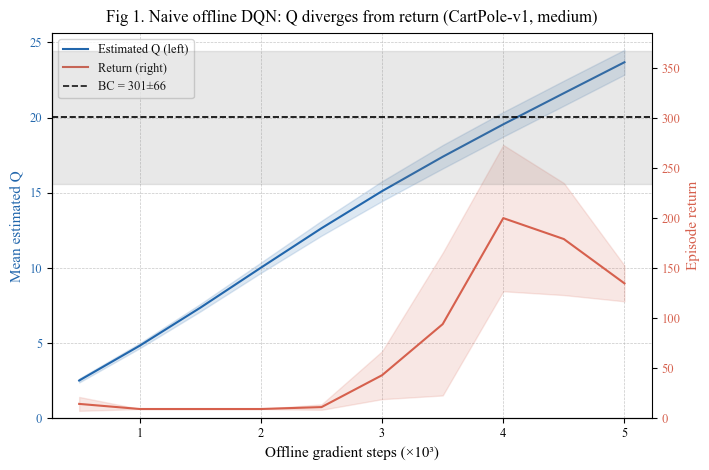

Saved fig1_ood_overestimation.pdf


In [8]:
fig, ax1 = plt.subplots(figsize=(7.2, 4.8))
x = np.arange(1, len(naive_ret[0]) + 1) * EVAL_EVERY / 1000.0
arr_q = np.array(naive_q); arr_r = np.array(naive_ret)
ax1.plot(x, arr_q.mean(0), color=BLUE, linewidth=1.5, label='Estimated Q (left)')
ax1.fill_between(x, arr_q.mean(0) - arr_q.std(0), arr_q.mean(0) + arr_q.std(0), color=BLUE, alpha=0.15)
ax1.set_xlabel('Offline gradient steps (×10³)')
ax1.set_ylabel('Mean estimated Q', color=BLUE)
ax1.tick_params(axis='y', labelcolor=BLUE)
ax1.set_ylim(bottom=0)
ax2 = ax1.twinx()
ax2.plot(x, arr_r.mean(0), color=RED, linewidth=1.5, label='Return (right)')
ax2.fill_between(x, arr_r.mean(0) - arr_r.std(0), arr_r.mean(0) + arr_r.std(0), color=RED, alpha=0.15)
add_bc_band(ax2, bc_mean, bc_std)
ax2.set_ylabel('Episode return', color=RED)
ax2.tick_params(axis='y', labelcolor=RED)
ax2.set_ylim(bottom=0)
style_axes(ax1)
ax1.set_title('Fig 1. Naive offline DQN: Q diverges from return (CartPole-v1, medium)', pad=8)
lines = ax1.get_lines() + ax2.get_lines()
ax1.legend(lines, [l.get_label() for l in lines], loc='upper left', fontsize=9)
fig.tight_layout()
fig.savefig(f'{DATA_DIR}/fig1_ood_overestimation.pdf', bbox_inches='tight')
plt.show()
print('Saved fig1_ood_overestimation.pdf')

---
## Figure 2 — CQL: the conservative penalty restores returns

CQL adds the `logsumexp_a Q(s,·) − Q(s,a_data)` regularizer to the Bellman error: minimizing the loss pushes down high-Q out-of-data actions and lifts in-data actions, steering greedy choices naturally onto the data support.

In [9]:
print(f'=== CQL alpha={CQL_ALPHA}（3 seeds）===')
cql_ret, cql_q = [], []
for sd in SEEDS:
    ret, q = train_offline_dqn(dataset, sd, cql_alpha=CQL_ALPHA)
    cql_ret.append(ret); cql_q.append(q)
    print(f'  seed {sd}: final ret={ret[-1]:.1f}, final Q={q[-1]:.1f}')

=== CQL alpha=1.0（3 seeds）===


  seed 42: final ret=360.7, final Q=23.3


  seed 43: final ret=308.1, final Q=23.5


  seed 44: final ret=288.5, final Q=23.6


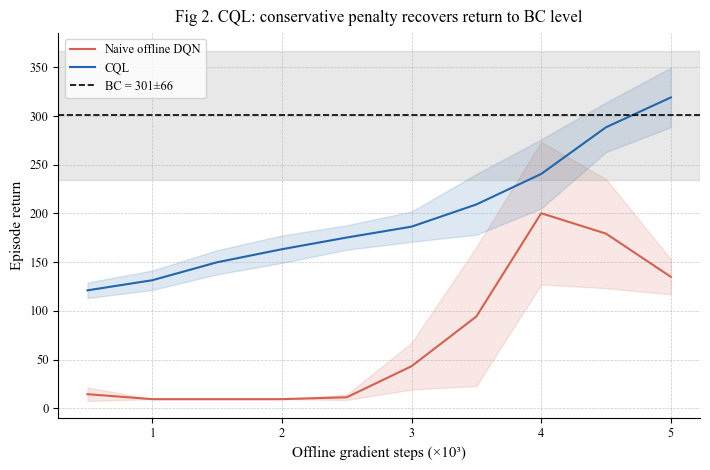

Saved fig2_cql_conservatism.pdf


In [10]:
fig, ax = plt.subplots(figsize=(7.2, 4.8))
plot_curve(ax, naive_ret, RED, 'Naive offline DQN')
plot_curve(ax, cql_ret, BLUE, 'CQL')
add_bc_band(ax, bc_mean, bc_std)
style_axes(ax)
ax.set_xlabel('Offline gradient steps (×10³)')
ax.set_ylabel('Episode return')
ax.set_title('Fig 2. CQL: conservative penalty recovers return to BC level', pad=8)
ax.legend(loc='upper left', fontsize=9)
fig.tight_layout()
fig.savefig(f'{DATA_DIR}/fig2_cql_conservatism.pdf', bbox_inches='tight')
plt.show()
print('Saved fig2_cql_conservatism.pdf')

---
## Figure 3 — IQL: in-sample learning restores returns

IQL fits V to an upper expectile of the in-data Q by expectile regression; Q's target is only `r + γV(s')` (no max), and the policy is trained by AWR-style weighted supervision --- it never queries out-of-data actions.

In [11]:
print(f'=== IQL tau={TAU} lam={LAM}（3 seeds）===')
iql_ret, iql_q = [], []
for sd in SEEDS:
    ret, q = train_iql(dataset, sd, tau=TAU, lam=LAM)
    iql_ret.append(ret); iql_q.append(q)
    print(f'  seed {sd}: final ret={ret[-1]:.1f}, final Q={q[-1]:.1f}')

=== IQL tau=0.7 lam=3.0（3 seeds）===


  seed 42: final ret=362.3, final Q=20.7


  seed 43: final ret=329.4, final Q=21.0


  seed 44: final ret=353.6, final Q=20.9


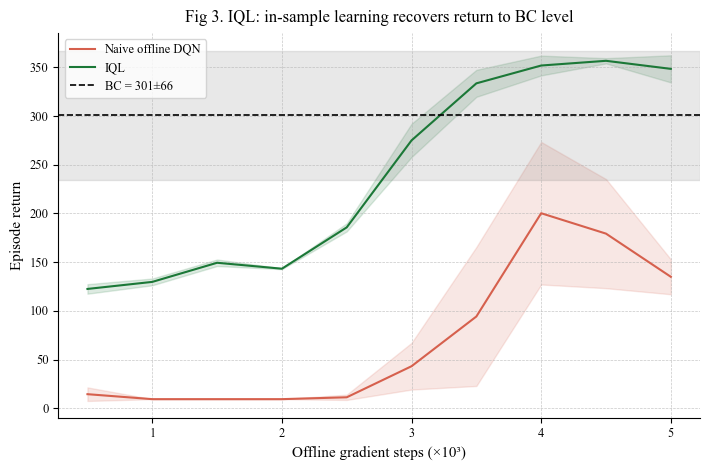

Saved fig3_iql_insample.pdf


In [12]:
fig, ax = plt.subplots(figsize=(7.2, 4.8))
plot_curve(ax, naive_ret, RED, 'Naive offline DQN')
plot_curve(ax, iql_ret, GREEN, 'IQL')
add_bc_band(ax, bc_mean, bc_std)
style_axes(ax)
ax.set_xlabel('Offline gradient steps (×10³)')
ax.set_ylabel('Episode return')
ax.set_title('Fig 3. IQL: in-sample learning recovers return to BC level', pad=8)
ax.legend(loc='upper left', fontsize=9)
fig.tight_layout()
fig.savefig(f'{DATA_DIR}/fig3_iql_insample.pdf', bbox_inches='tight')
plt.show()
print('Saved fig3_iql_insample.pdf')

---
## Summary

Measured numbers (3-seed means; BC = 300.9 ± 66.2):

| Method | Mechanism | Final mean return | vs BC band (235–367) |
|---|---|---|---|
| naive offline DQN | `max` probes out-of-data actions | ~135 | clearly below the band, collapsed |
| CQL | `logsumexp` penalty pushes OOD Q down | ~319 | inside the band, passing |
| IQL | expectile + no max | ~348 | inside the band, passing |

One disease (distribution shift / extrapolation error), two medicines: CQL writes pessimism into the value function, IQL into the action set.